# PaySim Preprocessing and Feature Engineering

This notebook prepares the PaySim dataset for tabular fraud modeling. The output is a ready-to-use engineered table saved into `data/interim/`.

The main goals are:
- clean and profile the raw PaySim transaction file
- engineer balance-consistency and behavioral features
- encode transaction types and account prefixes
- save a model-ready dataset for LightGBM or other tabular models

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "PS_20174392719_1491204439457_log.csv"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw file: {RAW_PATH}")

Project root: /Users/dienmayhaituyet/Documents/DataMining/COMP4040_Team12_FraudDetection
Raw file: /Users/dienmayhaituyet/Documents/DataMining/COMP4040_Team12_FraudDetection/data/raw/PS_20174392719_1491204439457_log.csv


## 2. Load data

In [2]:
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
df.head()

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
display(df.info())
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,6362620.0,NaN,NaN,NaN,243.397246,142.331971,1.0,156.0,239.0,335.0,743.0
type,6362620,5,CASH_OUT,2237500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,6362620.0,NaN,NaN,NaN,179861.903549,603858.231463,0.0,13389.57,74871.94,208721.4775,92445516.64
nameOrig,6362620,6353307,C2098525306,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,6362620.0,NaN,NaN,NaN,833883.104074,2888242.673038,0.0,0.0,14208.0,107315.175,59585040.37
newbalanceOrig,6362620.0,NaN,NaN,NaN,855113.668579,2924048.502954,0.0,0.0,0.0,144258.41,49585040.37
nameDest,6362620,2722362,C1286084959,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,6362620.0,NaN,NaN,NaN,1100701.66652,3399180.112994,0.0,0.0,132705.665,943036.7075,356015889.35
newbalanceDest,6362620.0,NaN,NaN,NaN,1224996.398202,3674128.94212,0.0,0.0,214661.44,1111909.25,356179278.92
isFraud,6362620.0,NaN,NaN,NaN,0.001291,0.035905,0.0,0.0,0.0,0.0,1.0


## 3. Core label and type inspection

,count,ratio
isFraud,,
0,6354407,0.998709
1,8213,0.001291


/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_22806/574007784.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="isFraud", palette="mako")


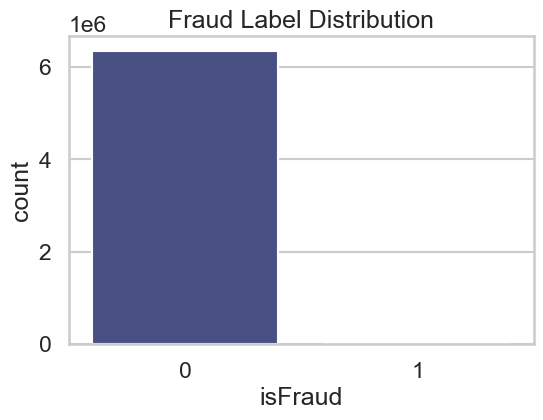

In [4]:
label_summary = pd.DataFrame({
    "count": df["isFraud"].value_counts().sort_index(),
    "ratio": (df["isFraud"].value_counts().sort_index() / len(df)).round(6),
})
display(label_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="isFraud", palette="mako")
plt.title("Fraud Label Distribution")
plt.show()

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


/var/folders/st/3lhx8lh109n5pxkwk6s4s6040000gn/T/ipykernel_22806/2561942763.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_share.index, y=fraud_share.values, palette="rocket")


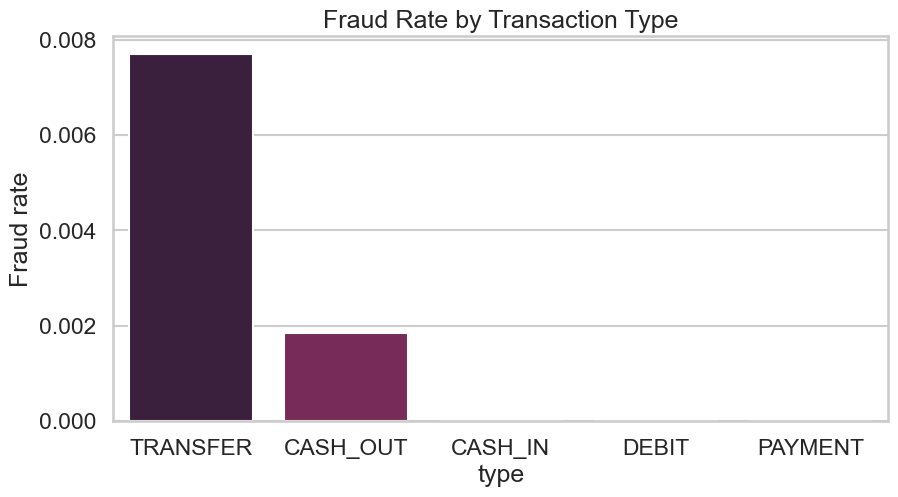

In [5]:
fraud_by_type = pd.crosstab(df["type"], df["isFraud"])
display(fraud_by_type)

plt.figure(figsize=(10, 5))
fraud_share = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
sns.barplot(x=fraud_share.index, y=fraud_share.values, palette="rocket")
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud rate")
plt.show()

## 4. Basic preprocessing

In [6]:
processed = df.copy()
processed["type"] = processed["type"].astype("string")
processed["nameOrig"] = processed["nameOrig"].astype("string")
processed["nameDest"] = processed["nameDest"].astype("string")

processed["orig_prefix"] = processed["nameOrig"].str[0]
processed["dest_prefix"] = processed["nameDest"].str[0]
processed["amount_log1p"] = np.log1p(processed["amount"].clip(lower=0))
processed.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_prefix,dest_prefix,amount_log1p
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,C,M,9.194276
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,C,M,7.531166
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,C,C,5.204007
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,C,C,5.204007
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,C,M,9.364703


## 5. PaySim-specific balance features

These are the most important engineered features for PaySim because fraud often shows up as balance inconsistencies.

In [7]:
processed["org_balance_delta"] = processed["oldbalanceOrg"] - processed["newbalanceOrig"]
processed["dest_balance_delta"] = processed["newbalanceDest"] - processed["oldbalanceDest"]
processed["org_delta_minus_amount"] = processed["org_balance_delta"] - processed["amount"]
processed["dest_delta_minus_amount"] = processed["dest_balance_delta"] - processed["amount"]

processed["org_zero_before"] = (processed["oldbalanceOrg"] == 0).astype(int)
processed["org_zero_after"] = (processed["newbalanceOrig"] == 0).astype(int)
processed["dest_zero_before"] = (processed["oldbalanceDest"] == 0).astype(int)
processed["dest_zero_after"] = (processed["newbalanceDest"] == 0).astype(int)

processed["org_balance_error_flag"] = (processed["org_delta_minus_amount"].abs() > 1e-6).astype(int)
processed["dest_balance_error_flag"] = (processed["dest_delta_minus_amount"].abs() > 1e-6).astype(int)

processed[[
    "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
    "org_balance_delta", "dest_balance_delta", "org_delta_minus_amount", "dest_delta_minus_amount"
]].head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,org_balance_delta,dest_balance_delta,org_delta_minus_amount,dest_delta_minus_amount
0,9839.64,170136.0,160296.36,0.0,0.0,9839.64,0.0,1.455192e-11,-9839.64
1,1864.28,21249.0,19384.72,0.0,0.0,1864.28,0.0,-1.136868e-12,-1864.28
2,181.00,181.0,0.00,0.0,0.0,181.00,0.0,0.000000e+00,-181.00
3,181.00,181.0,0.00,21182.0,0.0,181.00,-21182.0,0.000000e+00,-21363.00
4,11668.14,41554.0,29885.86,0.0,0.0,11668.14,0.0,0.000000e+00,-11668.14


## 6. Time-aware behavioral features

These use only earlier transactions when building history.

In [8]:
processed = processed.sort_values("step").reset_index(drop=True)
processed["tx_index"] = np.arange(len(processed))

processed["orig_tx_count_so_far"] = processed.groupby("nameOrig").cumcount()
processed["dest_tx_count_so_far"] = processed.groupby("nameDest").cumcount()
processed["orig_dest_pair_count_so_far"] = processed.groupby(["nameOrig", "nameDest"]).cumcount()

processed["prev_step_by_orig"] = processed.groupby("nameOrig")["step"].shift(1)
processed["prev_step_by_dest"] = processed.groupby("nameDest")["step"].shift(1)
processed["prev_step_by_pair"] = processed.groupby(["nameOrig", "nameDest"])["step"].shift(1)

processed["orig_step_gap"] = (processed["step"] - processed["prev_step_by_orig"]).fillna(0)
processed["dest_step_gap"] = (processed["step"] - processed["prev_step_by_dest"]).fillna(0)
processed["pair_step_gap"] = (processed["step"] - processed["prev_step_by_pair"]).fillna(0)

orig_amount_sum_before = processed.groupby("nameOrig")["amount"].cumsum() - processed["amount"]
dest_amount_sum_before = processed.groupby("nameDest")["amount"].cumsum() - processed["amount"]

processed["orig_amount_mean_before"] = orig_amount_sum_before.div(
    processed["orig_tx_count_so_far"].replace(0, np.nan)
).fillna(0)
processed["dest_amount_mean_before"] = dest_amount_sum_before.div(
    processed["dest_tx_count_so_far"].replace(0, np.nan)
).fillna(0)

processed["amount_vs_orig_mean"] = processed["amount"] - processed["orig_amount_mean_before"]
processed["amount_vs_dest_mean"] = processed["amount"] - processed["dest_amount_mean_before"]
processed[[
    "step", "nameOrig", "nameDest", "amount", "orig_tx_count_so_far",
    "dest_tx_count_so_far", "orig_step_gap", "dest_step_gap", "amount_vs_orig_mean"
]].head(10)

,step,nameOrig,nameDest,amount,orig_tx_count_so_far,dest_tx_count_so_far,orig_step_gap,dest_step_gap,amount_vs_orig_mean
0,1,C1231006815,M1979787155,9839.64,0,0,0.0,0.0,9839.64
1,1,C1562950869,M2021835850,5157.05,0,0,0.0,0.0,5157.05
2,1,C845388562,M550572371,5746.44,0,0,0.0,0.0,5746.44
3,1,C948424584,M1447685190,5607.36,0,0,0.0,0.0,5607.36
4,1,C2027701910,M1345293143,6360.79,0,0,0.0,0.0,6360.79
5,1,C1448277333,C243745864,67200.07,0,0,0.0,0.0,67200.07
6,1,C1340086277,M1427247001,2453.34,0,0,0.0,0.0,2453.34
7,1,C2034975583,M955443582,79.26,0,0,0.0,0.0,79.26
8,1,C2006842965,M842422776,3758.16,0,0,0.0,0.0,3758.16
9,1,C289711450,M1045567253,24495.45,0,0,0.0,0.0,24495.45


## 7. Transaction type encoding

In [9]:
type_dummies = pd.get_dummies(processed["type"], prefix="type", dtype=int)
processed = pd.concat([processed, type_dummies], axis=1)
processed.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,orig_prefix,dest_prefix,amount_log1p,org_balance_delta,dest_balance_delta,org_delta_minus_amount,dest_delta_minus_amount,org_zero_before,org_zero_after,dest_zero_before,dest_zero_after,org_balance_error_flag,dest_balance_error_flag,tx_index,orig_tx_count_so_far,dest_tx_count_so_far,orig_dest_pair_count_so_far,prev_step_by_orig,prev_step_by_dest,prev_step_by_pair,orig_step_gap,dest_step_gap,pair_step_gap,orig_amount_mean_before,dest_amount_mean_before,amount_vs_orig_mean,amount_vs_dest_mean,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.0,0,0,C,M,9.194276,9839.64,0.0,1.455192e-11,-9839.64,0,0,1,1,0,1,0,0,0,0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,9839.64,9839.64,0,0,0,1,0
1,1,PAYMENT,5157.05,C1562950869,1667.92,0.00,M2021835850,0.0,0.0,0,0,C,M,8.548314,1667.92,0.0,-3.489130e+03,-5157.05,0,1,1,1,1,1,1,0,0,0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,5157.05,5157.05,0,0,0,1,0
2,1,PAYMENT,5746.44,C845388562,0.00,0.00,M550572371,0.0,0.0,0,0,C,M,8.656510,0.00,0.0,-5.746440e+03,-5746.44,1,1,1,1,1,1,2,0,0,0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,5746.44,5746.44,0,0,0,1,0
3,1,PAYMENT,5607.36,C948424584,5202.00,0.00,M1447685190,0.0,0.0,0,0,C,M,8.632014,5202.00,0.0,-4.053600e+02,-5607.36,0,1,1,1,1,1,3,0,0,0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,5607.36,5607.36,0,0,0,1,0
4,1,PAYMENT,6360.79,C2027701910,3731.00,0.00,M1345293143,0.0,0.0,0,0,C,M,8.758065,3731.00,0.0,-2.629790e+03,-6360.79,0,1,1,1,1,1,4,0,0,0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,6360.79,6360.79,0,0,0,1,0


## 8. Useful visual checks for the engineered features

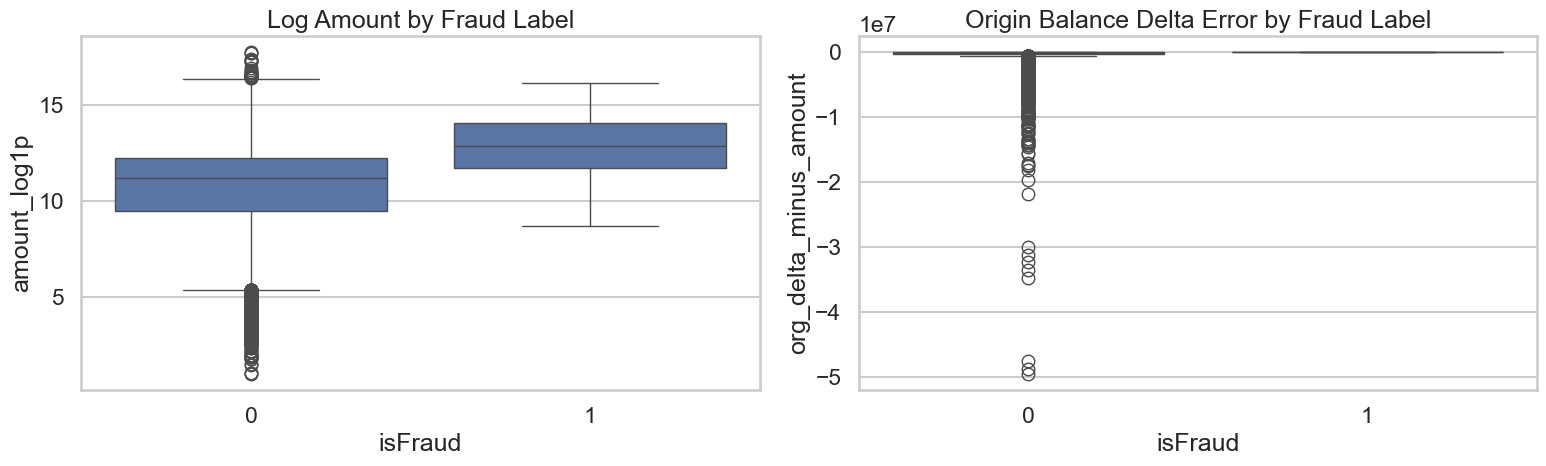

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=processed.sample(min(100000, len(processed)), random_state=42), x="isFraud", y="amount_log1p", ax=axes[0])
axes[0].set_title("Log Amount by Fraud Label")

sns.boxplot(data=processed.sample(min(100000, len(processed)), random_state=42), x="isFraud", y="org_delta_minus_amount", ax=axes[1])
axes[1].set_title("Origin Balance Delta Error by Fraud Label")
plt.tight_layout()
plt.show()

In [11]:
feature_preview = processed[[
    "step", "type", "amount", "amount_log1p", "nameOrig", "nameDest",
    "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
    "org_balance_delta", "dest_balance_delta",
    "org_delta_minus_amount", "dest_delta_minus_amount",
    "org_zero_before", "org_zero_after", "dest_zero_before", "dest_zero_after",
    "org_balance_error_flag", "dest_balance_error_flag",
    "orig_tx_count_so_far", "dest_tx_count_so_far", "orig_dest_pair_count_so_far",
    "orig_step_gap", "dest_step_gap", "pair_step_gap",
    "orig_amount_mean_before", "dest_amount_mean_before",
    "amount_vs_orig_mean", "amount_vs_dest_mean",
    "isFraud", "isFlaggedFraud"
] + [col for col in processed.columns if col.startswith("type_")]]
feature_preview.head()

,step,type,amount,amount_log1p,nameOrig,nameDest,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,org_balance_delta,dest_balance_delta,org_delta_minus_amount,dest_delta_minus_amount,org_zero_before,org_zero_after,dest_zero_before,dest_zero_after,org_balance_error_flag,dest_balance_error_flag,orig_tx_count_so_far,dest_tx_count_so_far,orig_dest_pair_count_so_far,orig_step_gap,dest_step_gap,pair_step_gap,orig_amount_mean_before,dest_amount_mean_before,amount_vs_orig_mean,amount_vs_dest_mean,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,PAYMENT,9839.64,9.194276,C1231006815,M1979787155,170136.00,160296.36,0.0,0.0,9839.64,0.0,1.455192e-11,-9839.64,0,0,1,1,0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,9839.64,9839.64,0,0,0,0,0,1,0
1,1,PAYMENT,5157.05,8.548314,C1562950869,M2021835850,1667.92,0.00,0.0,0.0,1667.92,0.0,-3.489130e+03,-5157.05,0,1,1,1,1,1,0,0,0,0.0,0.0,0.0,0.0,0.0,5157.05,5157.05,0,0,0,0,0,1,0
2,1,PAYMENT,5746.44,8.656510,C845388562,M550572371,0.00,0.00,0.0,0.0,0.00,0.0,-5.746440e+03,-5746.44,1,1,1,1,1,1,0,0,0,0.0,0.0,0.0,0.0,0.0,5746.44,5746.44,0,0,0,0,0,1,0
3,1,PAYMENT,5607.36,8.632014,C948424584,M1447685190,5202.00,0.00,0.0,0.0,5202.00,0.0,-4.053600e+02,-5607.36,0,1,1,1,1,1,0,0,0,0.0,0.0,0.0,0.0,0.0,5607.36,5607.36,0,0,0,0,0,1,0
4,1,PAYMENT,6360.79,8.758065,C2027701910,M1345293143,3731.00,0.00,0.0,0.0,3731.00,0.0,-2.629790e+03,-6360.79,0,1,1,1,1,1,0,0,0,0.0,0.0,0.0,0.0,0.0,6360.79,6360.79,0,0,0,0,0,1,0


## 9. Save ready-to-use interim dataset

In [12]:
output_path = INTERIM_DIR / "paysim_ready_features.csv"
feature_preview.to_csv(output_path, index=False)
print(f"Saved engineered dataset to: {output_path}")

Saved engineered dataset to: /Users/dienmayhaituyet/Documents/DataMining/COMP4040_Team12_FraudDetection/data/interim/paysim_ready_features.csv


## 10. Notes for downstream models

Recommended initial target:
- `isFraud`

Recommended columns to drop before training if needed:
- raw string IDs if the model cannot handle them directly
- `isFlaggedFraud` if you want a clean fraud target baseline

Recommended first model:
- LightGBM with time-based split on `step`

Recommended first comparisons:
- raw balance features only
- balance + behavioral history
- balance + behavioral history + type one-hot columns